<a href="https://colab.research.google.com/github/Sirigalla34/deep-learning-programs/blob/main/rnn_fp_and_bp_with_random_weights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

epoch: 100 loss: 0.5189999672965533
epoch: 200 loss: 0.06620097599928063
epoch: 300 loss: 0.033479298359891115
epoch: 400 loss: 0.022855001211415107
epoch: 500 loss: 0.017515066102866166
epoch: 600 loss: 0.014269217603608018
epoch: 700 loss: 0.012074044868499258
epoch: 800 loss: 0.010484241608688
Training converged at epoch: 838
Final loss: 0.009988537734065439
Final predictions:
[[0.]
 [1.]
 [0.]]
[[0.]
 [0.]
 [1.]]
[[1.]
 [0.]
 [0.]]


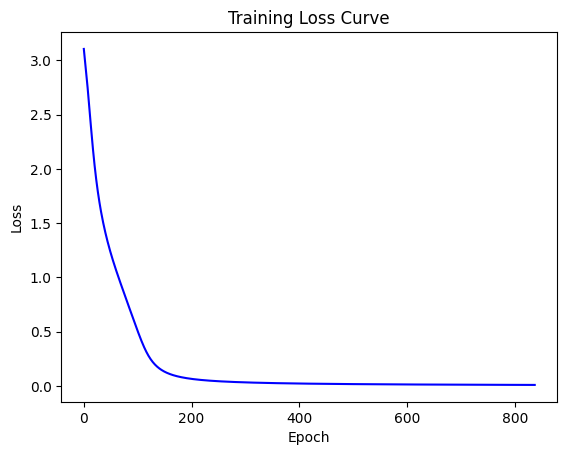

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True)
def softmax(x):
    exp_x=np.exp(x-np.max(x))
    return exp_x/np.sum(exp_x)
def cross_entropy(y_true,y_pred):
    return -np.sum(y_true*np.log(y_pred+1e-12))
def clip_gradients(g,v):
    return np.clip(g,-v,v)
learning_rate=0.1
epochs=1000
clip_value=1
threshold=0.01
Wxh=np.array([[-0.1,0.2,0.3],[0.4,0.5,0.6]])
Whh=np.array([[0.7,0.8],[0.9,0.1]])
Why=np.array([[1.0,0.2],[0.3,0.4],[0.5,0.6]])
bh=np.array([[0.0],[0.0]])
by=np.array([[0.0],[0.0],[0.0]])
x1=np.array([[1],[0],[0]])
x2=np.array([[0],[1],[0]])
x3=np.array([[0],[0],[1]])
inputs=[x1,x2,x3]
t1=np.array([[0],[1],[0]])
t2=np.array([[0],[0],[1]])
t3=np.array([[1],[0],[0]])
targets=[t1,t2,t3]
loss_history=[]
for epoch in range(epochs):
    h0=np.zeros((2,1))
    hs=[h0]
    ps=[]
    loss=0
    for t in range(3):
        ht=np.tanh(Wxh@inputs[t]+Whh@hs[t]+bh)
        y=Why@ht+by
        p=softmax(y)
        hs.append(ht)
        ps.append(p)
        loss+=cross_entropy(targets[t],p)
    loss_history.append(loss)
    if loss<threshold:
        print("Training converged at epoch:",epoch+1)
        break
    dWxh=np.zeros_like(Wxh)
    dWhh=np.zeros_like(Whh)
    dWhy=np.zeros_like(Why)
    dbh=np.zeros_like(bh)
    dby=np.zeros_like(by)
    dh_next=np.zeros_like(h0)
    for t in reversed(range(3)):
        dy=ps[t]-targets[t]
        dWhy+=dy@hs[t+1].T
        dby+=dy
        dh=Why.T@dy+dh_next
        dt=(1-hs[t+1]**2)*dh
        dWxh+=dt@inputs[t].T
        dWhh+=dt@hs[t].T
        dbh+=dt
        dh_next=Whh.T@dt
    dWxh=clip_gradients(dWxh,clip_value)
    dWhh=clip_gradients(dWhh,clip_value)
    dWhy=clip_gradients(dWhy,clip_value)
    dbh=clip_gradients(dbh,clip_value)
    dby=clip_gradients(dby,clip_value)
    Wxh-=learning_rate*dWxh
    Whh-=learning_rate*dWhh
    Why-=learning_rate*dWhy
    bh-=learning_rate*dbh
    by-=learning_rate*dby
    if (epoch+1)%100==0:
        print("epoch:",epoch+1,"loss:",loss)
print("Final loss:",loss)
print("Final predictions:")
for t in range(3):
    print(np.round(ps[t],1))
plt.plot(loss_history,color='blue')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()